In [1]:
!pip install cantera -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.6 MB/s eta 0:00:00


In [2]:
import cantera as ct
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

print(f"Cantera version : {ct.__version__}")
print("All imports loaded successfully.")

Cantera version : 3.2.0
All imports loaded successfully.


In [3]:
np.random.seed(7)
random.seed(7)

gas = ct.Solution('h2o2.yaml')
print(f"Mechanism loaded : h2o2.yaml")
print(f"Species ({gas.n_species}) : {gas.species_names}")
print(f"Reactions        : {gas.n_reactions}")
print()

records  = []
attempts = 0
n_target = 1000

while len(records) < n_target:
    attempts += 1

    T_init = random.uniform(500, 1500)
    P_init = random.uniform(0.5 * ct.one_atm, 10 * ct.one_atm)
    phi    = random.uniform(0.3, 2.5)
    t_max  = random.uniform(0.001, 0.5)

    try:
        gas.set_equivalence_ratio(phi, 'H2', {'O2': 1.0, 'N2': 3.76})
        gas.TP = T_init, P_init

        reactor = ct.IdealGasReactor(gas, energy='on')
        net     = ct.ReactorNet([reactor])
        net.advance(t_max)

        T_final    = reactor.T
        P_final    = reactor.thermo.P
        delta_T    = T_final - T_init
        H2_remain  = reactor.thermo['H2'].X[0]
        H2O_formed = reactor.thermo['H2O'].X[0]
        OH_conc    = reactor.thermo['OH'].X[0]
        HO2_conc   = reactor.thermo['HO2'].X[0]
        O2_remain  = reactor.thermo['O2'].X[0]

        ignited = 1 if delta_T > 300 else 0

        records.append({
            'T_init'    : round(T_init,    4),
            'P_init'    : round(P_init,    2),
            'phi'       : round(phi,       4),
            't_max'     : round(t_max,     5),
            'T_final'   : round(T_final,   4),
            'P_final'   : round(P_final,   2),
            'delta_T'   : round(delta_T,   4),
            'H2_remain' : round(H2_remain, 6),
            'H2O_formed': round(H2O_formed,6),
            'OH_conc'   : round(OH_conc,   8),
            'HO2_conc'  : round(HO2_conc,  8),
            'O2_remain' : round(O2_remain, 6),
            'ignited'   : ignited
        })

    except Exception:
        continue

df = pd.DataFrame(records)
print(f"Simulations completed : {len(df)}  (from {attempts} attempts)")
print(f"Ignition rate         : {df['ignited'].mean()*100:.1f}%")
df.head(8)

Mechanism loaded : h2o2.yaml
Species (10) : ['H2', 'H', 'O', 'O2', 'OH', 'H2O', 'HO2', 'H2O2', 'AR', 'N2']
Reactions        : 29

Simulations completed : 1000  (from 1000 attempts)
Ignition rate         : 58.8%


,T_init,P_init,phi,t_max,T_final,P_final,delta_T,H2_remain,H2O_formed,OH_conc,HO2_conc,O2_remain,ignited
0,823.8328,195868.03,1.7321,0.03715,823.8329,195868.05,0.0001,0.421214,0.000000,0.000000,2.000000e-08,0.121594,0
1,1035.8820,402670.08,0.4276,0.25421,2364.1393,850872.06,1328.2573,0.000500,0.161020,0.005829,1.300000e-05,0.108502,1
2,537.4957,468084.41,0.4537,0.04627,537.4957,468084.41,-0.0000,0.160103,0.000000,0.000000,0.000000e+00,0.176449,0
3,924.5192,846580.02,0.5724,0.11240,2588.6607,2149433.27,1664.1415,0.001455,0.207241,0.009871,2.620000e-05,0.077516,1
4,1127.4332,962915.28,1.5696,0.19894,3104.9077,2352984.88,1977.4744,0.160749,0.272701,0.010917,1.970000e-06,0.000492,1
5,1476.2551,95502.41,2.1886,0.14552,2909.1387,173011.55,1432.8836,0.267777,0.223815,0.012095,6.000000e-07,0.000437,1
6,644.2551,164047.84,0.9787,0.40825,644.2551,164047.84,0.0000,0.291384,0.000000,0.000000,0.000000e+00,0.148869,0
7,680.7264,610503.55,1.7056,0.18683,680.7264,610503.55,0.0000,0.417468,0.000000,0.000000,0.000000e+00,0.122381,0


In [4]:
print("Dataset shape:", df.shape)
print()
print(df.describe().round(4).to_string())

Dataset shape: (1000, 13)

          T_init        P_init        phi      t_max    T_final       P_final    delta_T  H2_remain  H2O_formed    OH_conc   HO2_conc  O2_remain    ignited
count  1000.0000  1.000000e+03  1000.0000  1000.0000  1000.0000  1.000000e+03  1000.0000  1000.0000   1000.0000  1000.0000  1000.0000  1000.0000  1000.0000
mean    984.9474  5.391949e+05     1.3879     0.2463  2008.2455  9.622789e+05  1023.2981     0.2224      0.1408     0.0088     0.0000     0.0699     0.5880
std     287.9600  2.849813e+05     0.6403     0.1443  1113.1716  6.844375e+05   873.9255     0.1517      0.1210     0.0105     0.0000     0.0651     0.4924
min     501.2991  5.083450e+04     0.3005     0.0015   501.2991  5.238646e+04    -0.0000     0.0000      0.0000     0.0000     0.0000     0.0000     0.0000
25%     733.3753  2.898130e+05     0.8258     0.1233   733.3753  3.935158e+05    -0.0000     0.0928      0.0000     0.0000     0.0000     0.0008     0.0000
50%     973.2476  5.369812e+05     1.

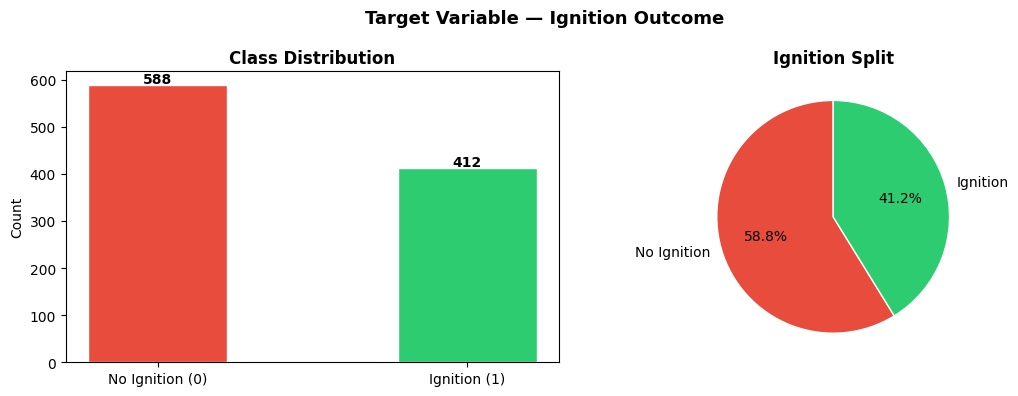

In [5]:
counts = df['ignited'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No Ignition (0)', 'Ignition (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.45)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Ignition', 'Ignition'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Ignition Split', fontweight='bold')

plt.suptitle('Target Variable — Ignition Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

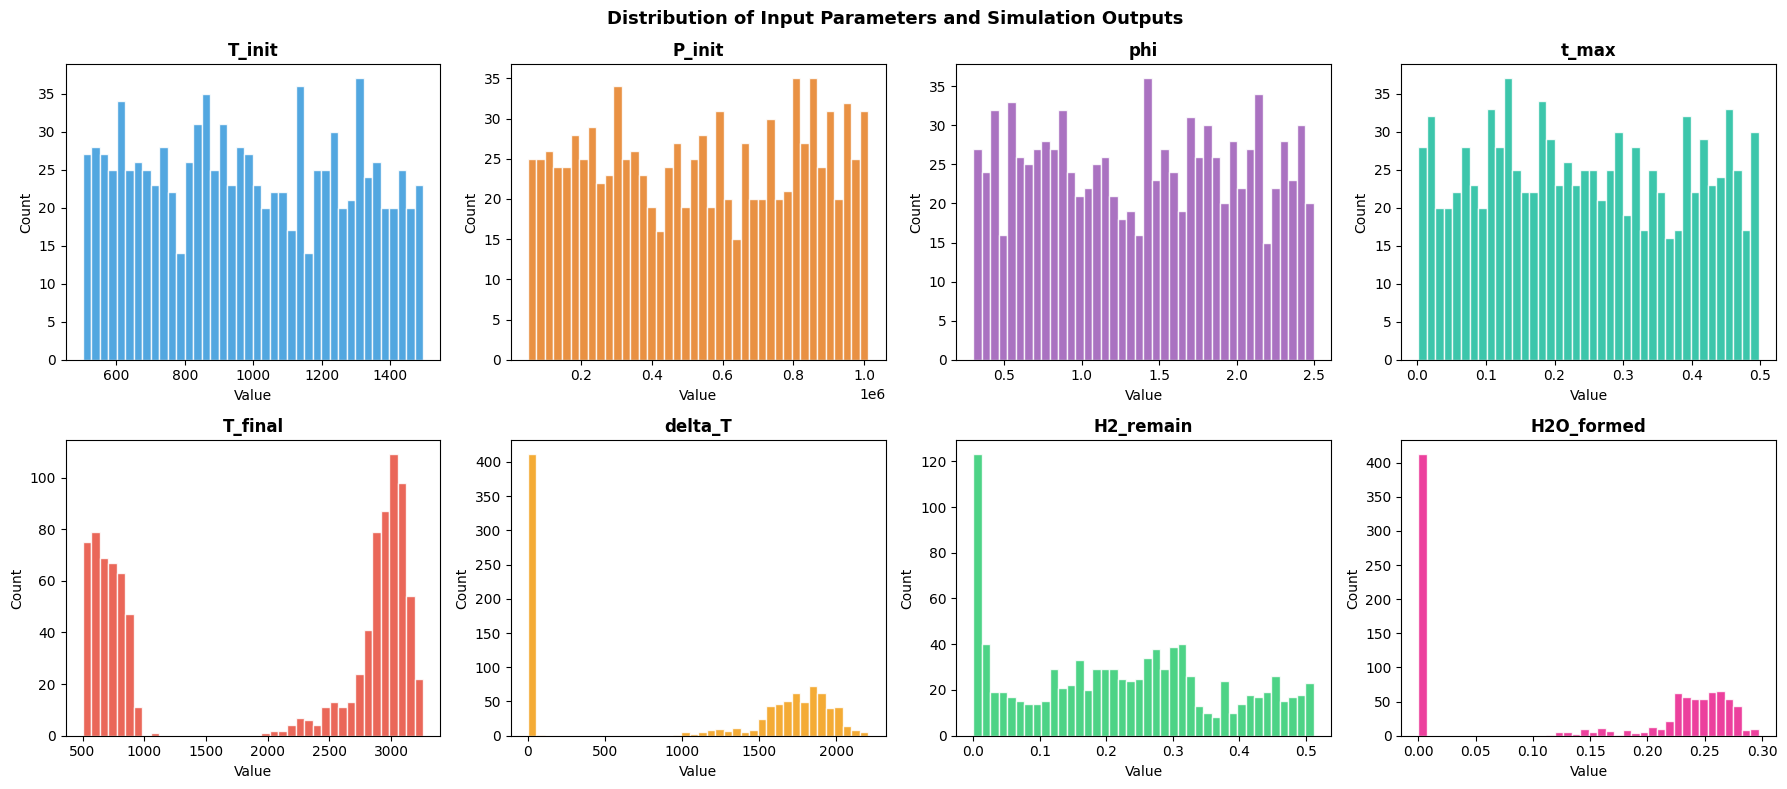

In [6]:
plot_features = ['T_init', 'P_init', 'phi', 't_max', 'T_final', 'delta_T', 'H2_remain', 'H2O_formed']
palette = ['#3498db','#e67e22','#9b59b6','#1abc9c','#e74c3c','#f39c12','#2ecc71','#e91e8c']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution of Input Parameters and Simulation Outputs', fontsize=13, fontweight='bold')

for ax, feat, color in zip(axes.flatten(), plot_features, palette):
    ax.hist(df[feat], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

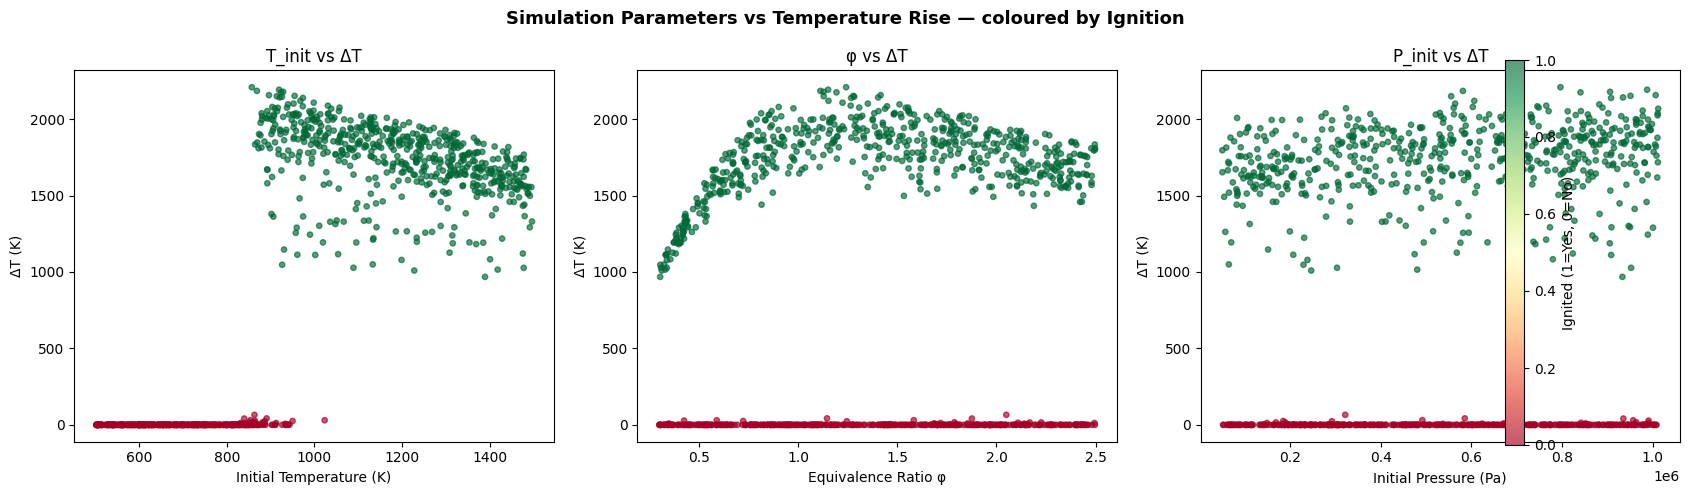

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sc = axes[0].scatter(df['T_init'], df['delta_T'], c=df['ignited'],
                     cmap='RdYlGn', s=15, alpha=0.65)
axes[0].set_xlabel('Initial Temperature (K)')
axes[0].set_ylabel('ΔT (K)')
axes[0].set_title('T_init vs ΔT')

axes[1].scatter(df['phi'], df['delta_T'], c=df['ignited'],
                cmap='RdYlGn', s=15, alpha=0.65)
axes[1].set_xlabel('Equivalence Ratio φ')
axes[1].set_ylabel('ΔT (K)')
axes[1].set_title('φ vs ΔT')

axes[2].scatter(df['P_init'], df['delta_T'], c=df['ignited'],
                cmap='RdYlGn', s=15, alpha=0.65)
axes[2].set_xlabel('Initial Pressure (Pa)')
axes[2].set_ylabel('ΔT (K)')
axes[2].set_title('P_init vs ΔT')

fig.colorbar(sc, ax=axes, label='Ignited (1=Yes, 0=No)',
             orientation='vertical', fraction=0.015, pad=0.04)
fig.suptitle('Simulation Parameters vs Temperature Rise — coloured by Ignition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

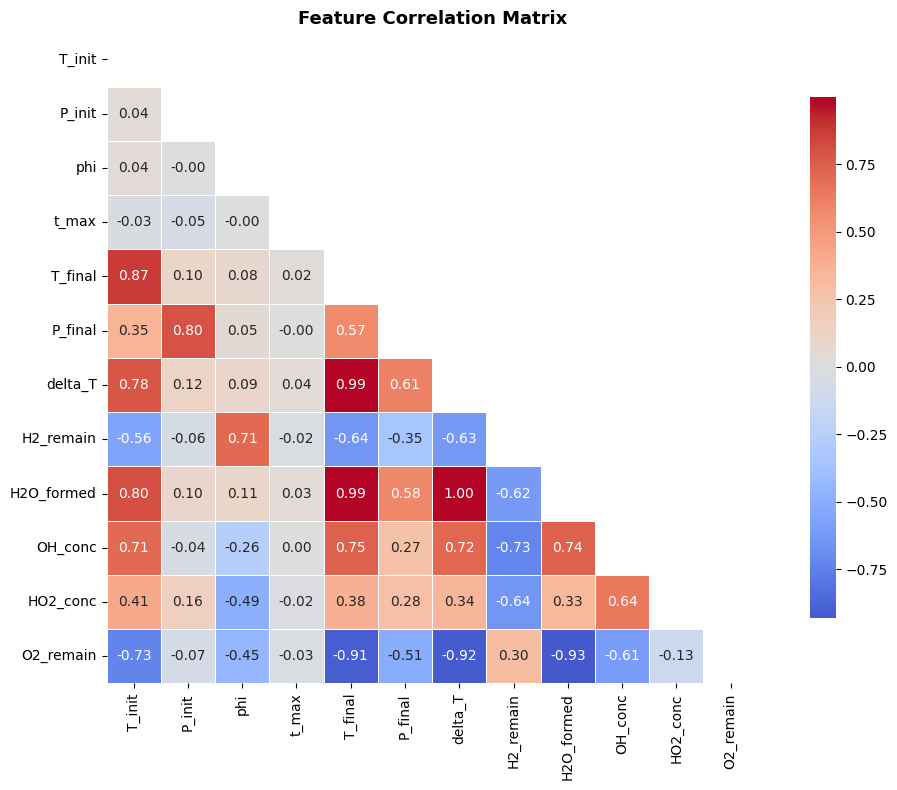

In [8]:
plt.figure(figsize=(11, 8))
corr = df.drop(columns=['ignited']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
feature_cols = [
    'T_init', 'P_init', 'phi', 't_max',
    'T_final', 'P_final', 'H2_remain',
    'H2O_formed', 'OH_conc', 'HO2_conc', 'O2_remain'
]

X = df[feature_cols]
y = df['ignited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features used    : {len(feature_cols)}")

Training samples : 800
Testing  samples : 200
Features used    : 11


In [10]:
models = {
    'Logistic Regression' : (LogisticRegression(max_iter=500, random_state=42),            True),
    'Decision Tree'       : (DecisionTreeClassifier(max_depth=8, random_state=42),          False),
    'Random Forest'       : (RandomForestClassifier(n_estimators=150, random_state=42),     False),
    'Gradient Boosting'   : (GradientBoostingClassifier(n_estimators=150, random_state=42), False),
    'AdaBoost'            : (AdaBoostClassifier(n_estimators=100, random_state=42),          False),
    'SVM (RBF)'           : (SVC(kernel='rbf', probability=True, random_state=42),           True),
    'KNN'                 : (KNeighborsClassifier(n_neighbors=7),                            True),
    'Naive Bayes'         : (GaussianNB(),                                                   False),
    'MLP Neural Network'  : (MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                           max_iter=600, random_state=42),                   True),
}

results = []

for name, (model, scaled) in models.items():
    Xtr = X_train_sc if scaled else X_train
    Xte = X_test_sc  if scaled else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, preds),  4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall'   : round(recall_score(y_test, preds),    4),
        'F1 Score' : round(f1_score(y_test, preds),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, probs),   4),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('F1 Score', ascending=False)
    .reset_index(drop=True)
)
results_df.index += 1
print(results_df.to_string())

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1  Logistic Regression       1.0        1.0     1.0       1.0      1.0
2        Decision Tree       1.0        1.0     1.0       1.0      1.0
3        Random Forest       1.0        1.0     1.0       1.0      1.0
4    Gradient Boosting       1.0        1.0     1.0       1.0      1.0
5             AdaBoost       1.0        1.0     1.0       1.0      1.0
6            SVM (RBF)       1.0        1.0     1.0       1.0      1.0
7                  KNN       1.0        1.0     1.0       1.0      1.0
8          Naive Bayes       1.0        1.0     1.0       1.0      1.0
9   MLP Neural Network       1.0        1.0     1.0       1.0      1.0


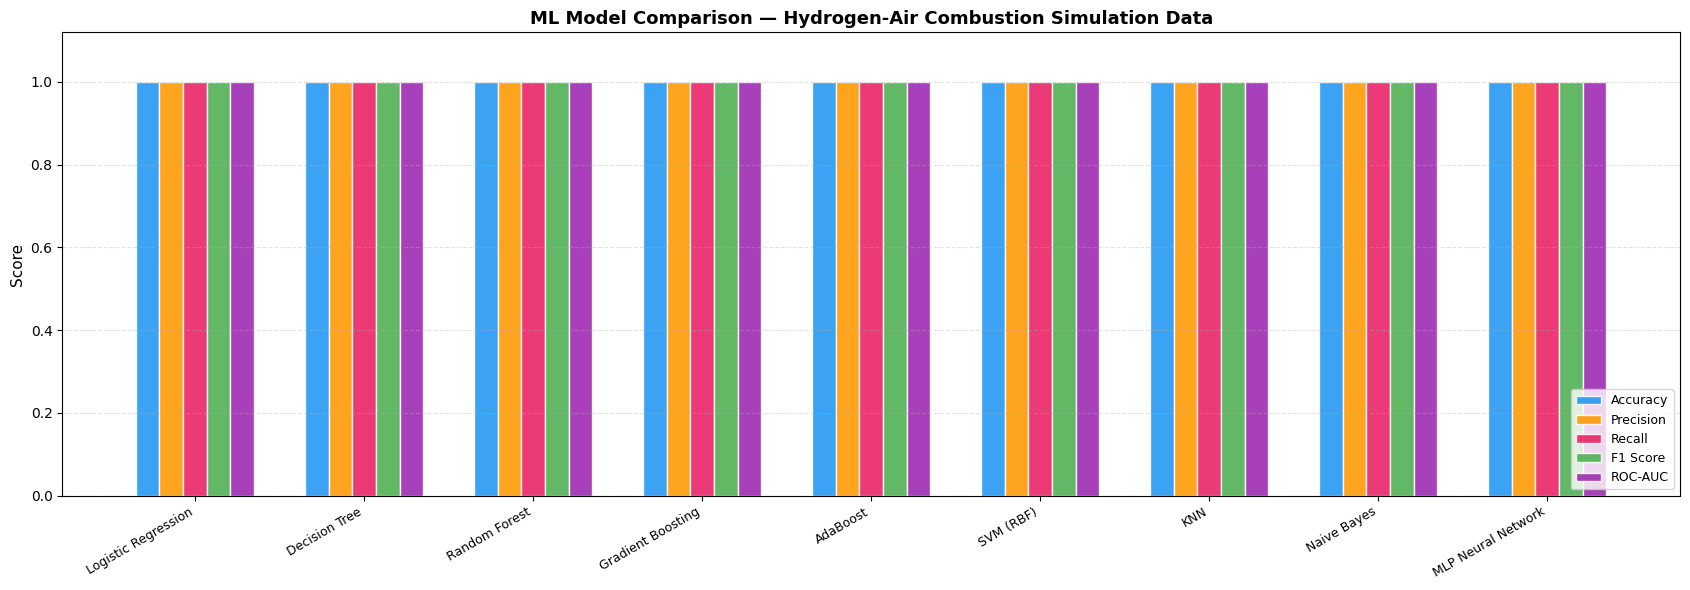

In [11]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x       = np.arange(len(results_df))
width   = 0.14
colors  = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50', '#9C27B0']

fig, ax = plt.subplots(figsize=(17, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width,
           label=metric, color=color, alpha=0.88, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('ML Model Comparison — Hydrogen-Air Combustion Simulation Data',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

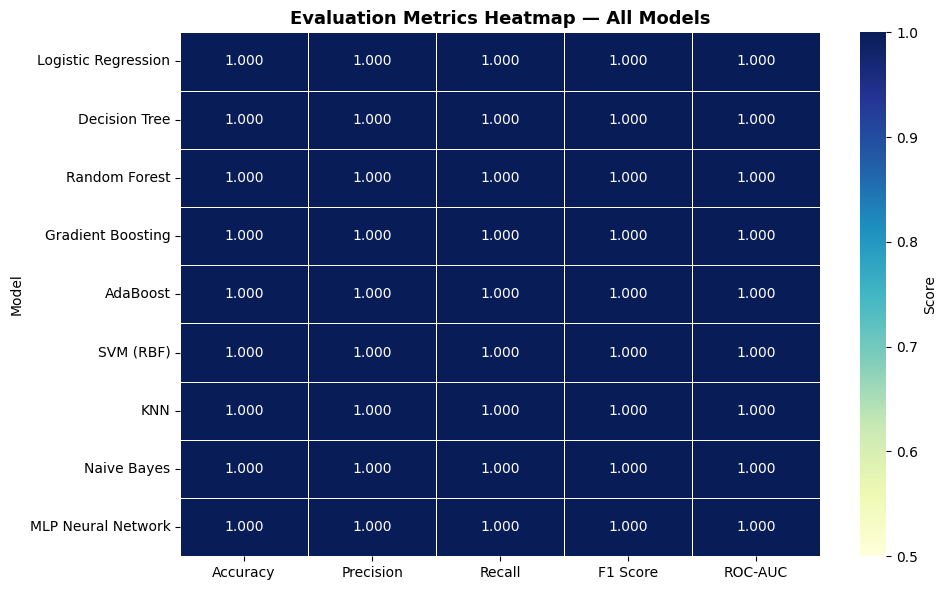

In [12]:
pivot = results_df.set_index('Model')[metrics]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, vmin=0.5, vmax=1.0,
            cbar_kws={'label': 'Score'})
plt.title('Evaluation Metrics Heatmap — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

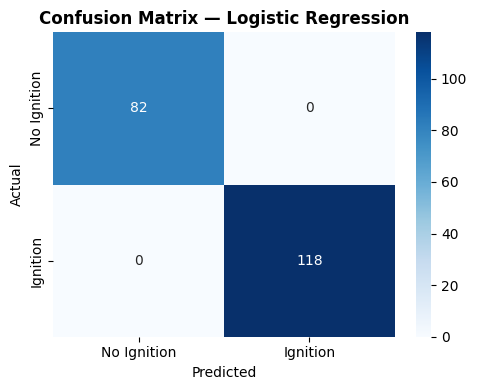

Best model : Logistic Regression
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
ROC-AUC                      1.0


In [13]:
best_name          = results_df.iloc[0]['Model']
best_model, best_scaled = models[best_name]
Xte_best           = X_test_sc if best_scaled else X_test
best_preds         = best_model.predict(Xte_best)
cm                 = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Ignition', 'Ignition'],
            yticklabels=['No Ignition', 'Ignition'])
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"Best model : {best_name}")
print(results_df.iloc[0].to_string())

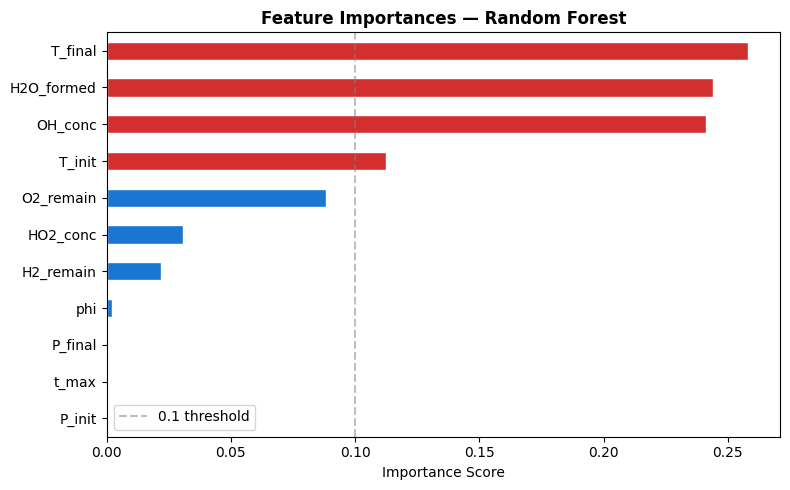

In [14]:
rf_model    = models['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
bar_colors  = ['#d32f2f' if v > 0.1 else '#1976d2' for v in importances.values]

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color=bar_colors, edgecolor='white')
plt.title('Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='0.1 threshold')
plt.legend()
plt.tight_layout()
plt.show()

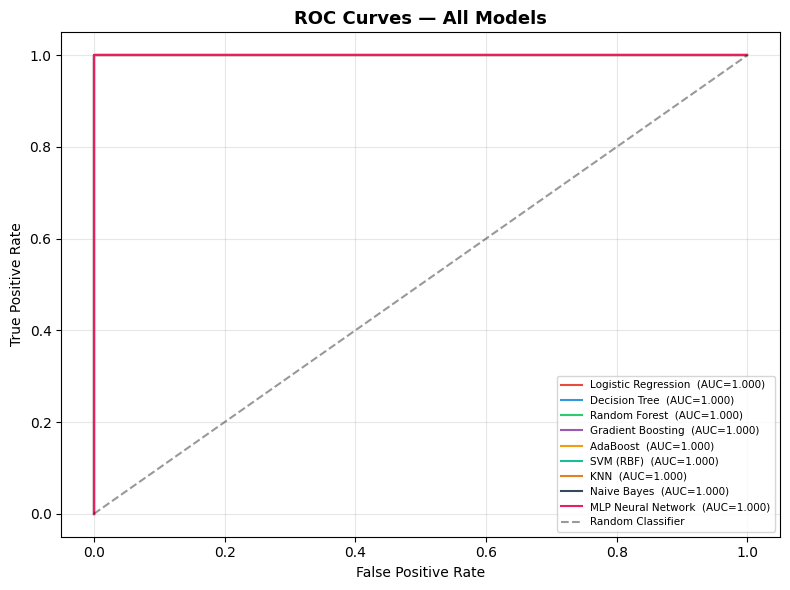

In [15]:
line_colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6',
               '#f39c12','#1abc9c','#e67e22','#34495e','#e91e63']

plt.figure(figsize=(8, 6))

for (name, (model, scaled)), color in zip(models.items(), line_colors):
    Xte   = X_test_sc if scaled else X_test
    probs = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc   = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=1.5, label=f'{name}  (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=7.5, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()